### Log Normal Distribution

In [38]:
import pandas as pd
import numpy as np
from scipy.stats import norm,lognorm
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt

In [9]:
data =  yf.download(tickers='AAPL',period='1y',auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [10]:
data

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2025-06-26,200.205750,201.000000,202.639999,199.460007,201.429993,50799100
2025-06-27,200.285431,201.080002,203.220001,200.000000,201.889999,73188600
2025-06-30,204.359253,205.169998,207.389999,199.259995,202.009995,91912800
2025-07-01,206.998779,207.820007,210.190002,206.139999,206.669998,78788900
2025-07-02,211.600540,212.440002,213.339996,208.139999,208.910004,67941800
...,...,...,...,...,...,...
2026-06-18,298.010010,298.010010,300.570007,295.619995,298.109985,85962200
2026-06-22,297.010010,297.010010,302.420013,296.760010,297.309998,44879900


first we assume that Close price is Log Normal distribution and plot this
then convert Log normal distribution to a normal distribution - 
 - then check it is complete normal distribution or not

In [11]:
data['Adj Close'].isna().sum()

Ticker
AAPL    0
dtype: int64

In [12]:
prices  = data['Adj Close'].dropna()
prices

Ticker,AAPL
Date,
2025-06-26,200.205750
2025-06-27,200.285431
2025-06-30,204.359253
2025-07-01,206.998779
2025-07-02,211.600540
...,...
2026-06-18,298.010010
2026-06-22,297.010010
2026-06-23,294.299988


In [26]:
prices = prices['AAPL']

In [27]:
prices.info()

<class 'pandas.Series'>
DatetimeIndex: 251 entries, 2025-06-26 to 2026-06-25
Series name: AAPL
Non-Null Count  Dtype  
--------------  -----  
251 non-null    float64
dtypes: float64(1)
memory usage: 3.9 KB


In [30]:
print(type(prices))

<class 'pandas.Series'>


In [34]:
# first assuming that this is a log normal distribution
shape, loc, scale =lognorm.fit(prices)


# min(prices) → prices ka smallest value
# max(prices) → prices ka largest value
# 100 → inke beech 100 equally spaced points banao
x = np.linspace(min(prices),max(prices),100)

# we get 3 values
    # -- shape , location and scale


In [44]:
# draw pdf of this distribution
pdf_lognorm = lognorm.pdf(x, shape, loc=loc, scale=scale)

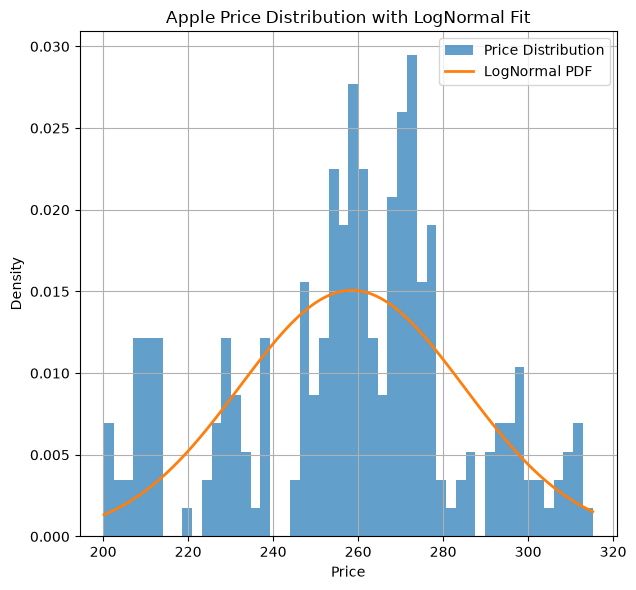

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
# Histogram ko probability density mein convert karo
# Y-axis pe:
# Probability Density
# show hota hai.
# keyword ke saath likhna readable hota hai. - alpha=0.7
plt.hist(
    prices,
    bins=50,
    density=True,
    alpha=0.7,
    label='Price Distribution'
)

plt.plot(
    x,
    pdf_lognorm,
    linewidth=2,
    label='LogNormal PDF'
)

plt.xlabel('Price')
plt.ylabel('Density')
plt.title('Apple Price Distribution with LogNormal Fit')

plt.legend()
plt.grid()

plt.tight_layout()

plt.show()

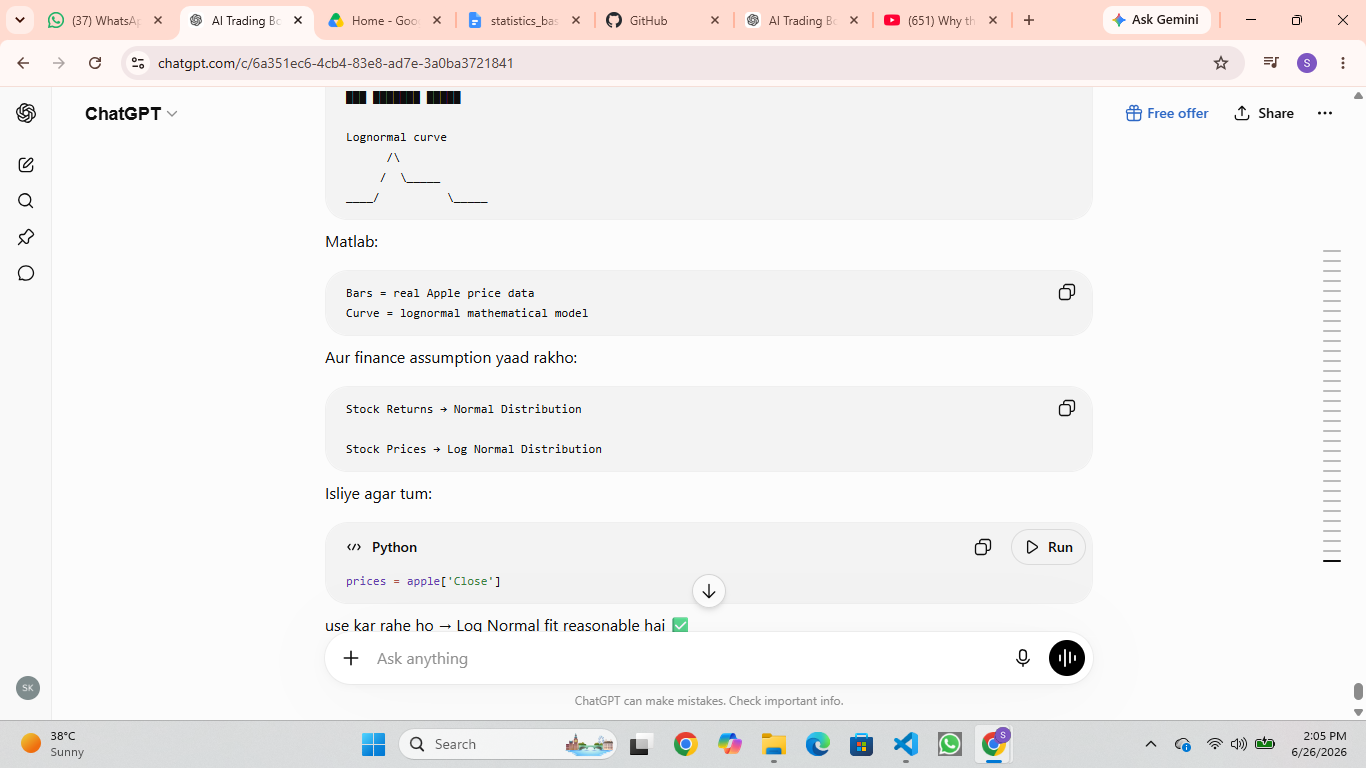

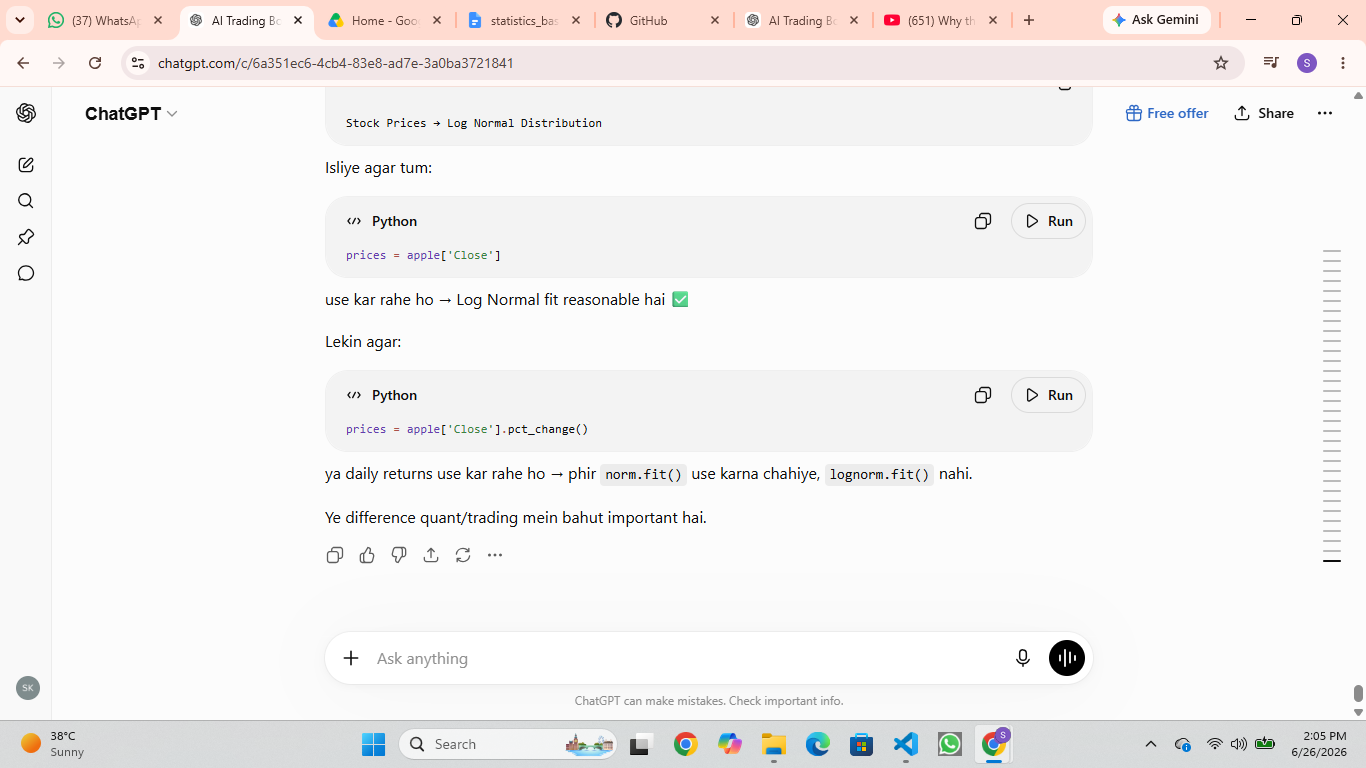

## Log Normal distribution